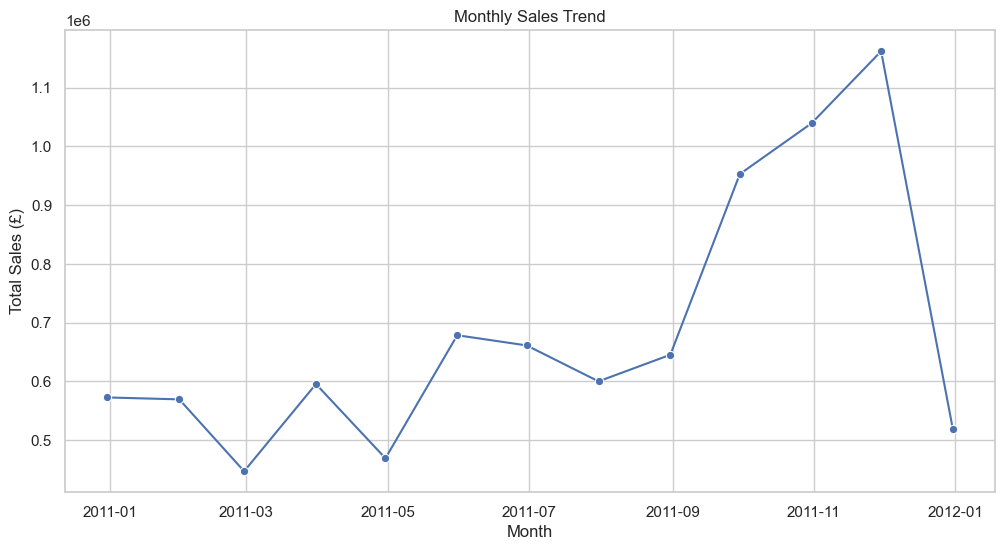

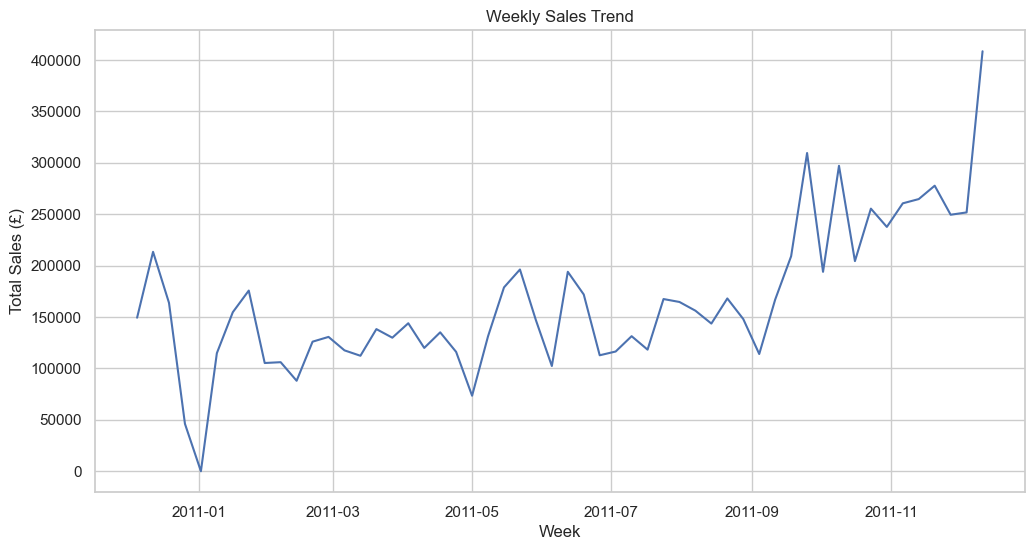

C:\Users\divin\AppData\Local\Temp\ipykernel_11500\3555894577.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


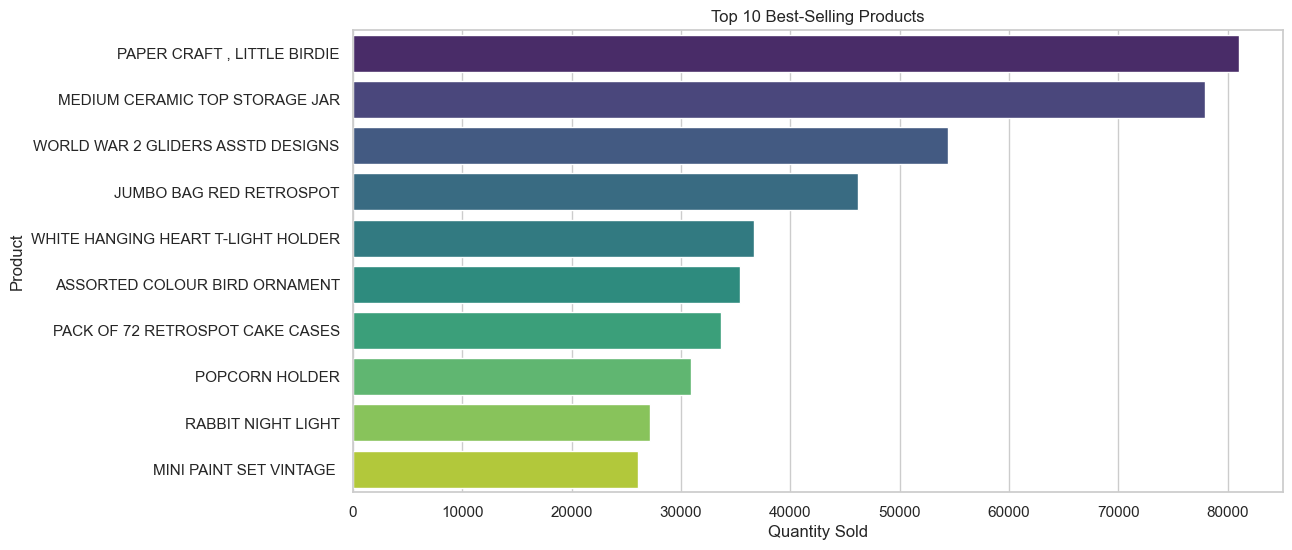

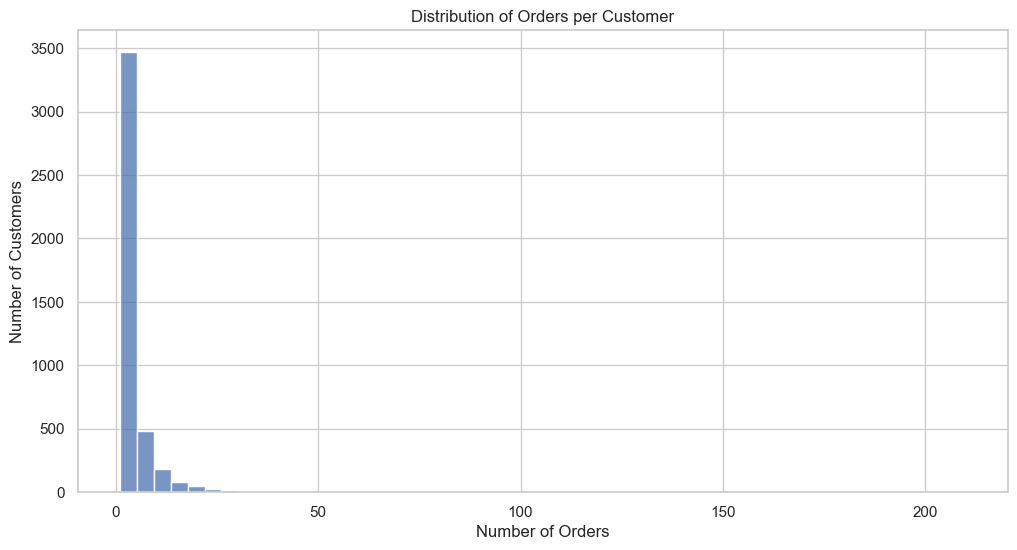

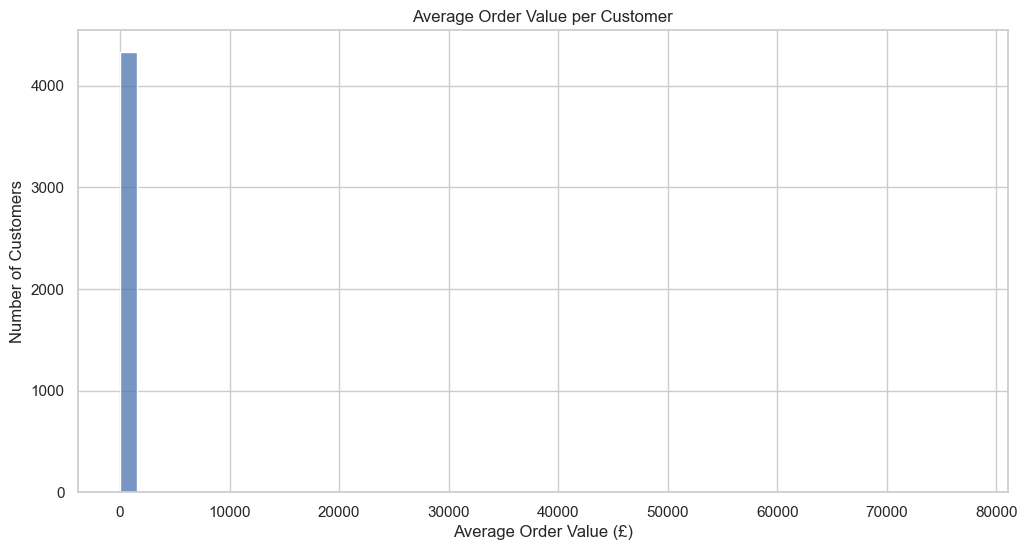

C:\Users\divin\AppData\Local\Temp\ipykernel_11500\3555894577.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, palette="coolwarm")


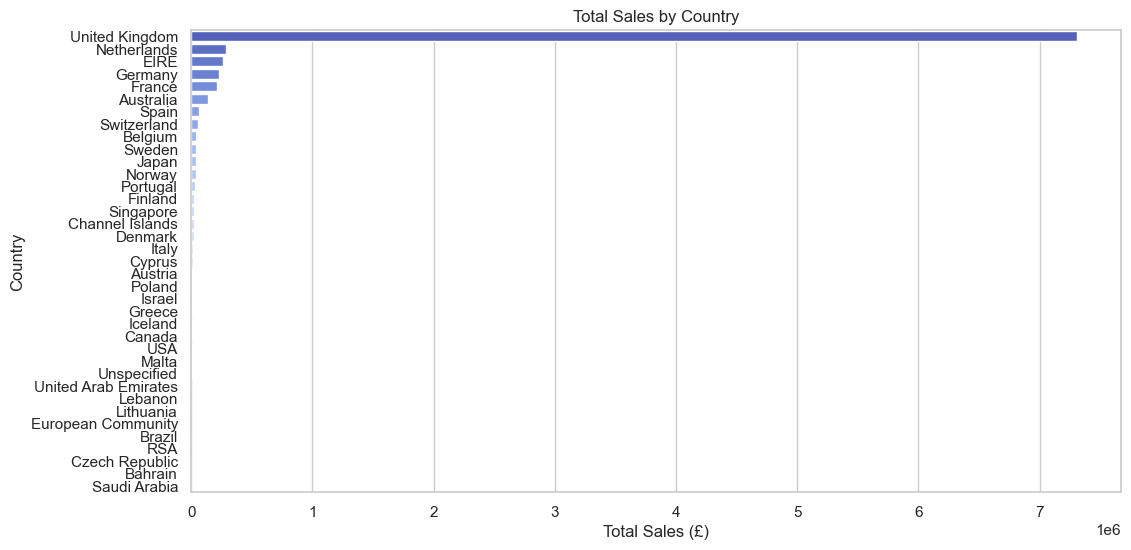

Large Orders (>100 units):
    InvoiceNo                          Description  Quantity  TotalPrice
96     536378      PACK OF 72 RETROSPOT CAKE CASES       120       50.40
178    536387                        CHILLI LIGHTS       192      733.44
179    536387       LIGHT GARLAND BUTTERFILES PINK       192      647.04
180    536387           WOODEN OWLS LIGHT GARLAND        192      647.04
181    536387        FAIRY TALE COTTAGE NIGHTLIGHT       432      626.40
182    536387        RED TOADSTOOL LED NIGHT LIGHT       432      540.00
217    536390    HANGING HEART ZINC T-LIGHT HOLDER       144       92.16
219    536390      DISCO BALL CHRISTMAS DECORATION       288       28.80
227    536390                   POLKADOT RAIN HAT        144       46.08
415    536405  SET/5 RED RETROSPOT LID GLASS BOWLS       128      326.40

Key Takeaways:
- Peak sales occur during holidays → plan promotions.
- Top products drive majority of sales → ensure stock availability.
- Repeat customers contribute si

In [34]:
# ------------------------------
# Online Retail Storytelling Project
# ------------------------------

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

# ------------------------------
# Step 2: Load Data
# ------------------------------
df = pd.read_csv(r"M:\Stry_telling\data.csv", encoding='ISO-8859-1')

# ------------------------------
# Step 3: Clean Data
# ------------------------------
df = df.dropna(subset=['CustomerID'])  # Remove missing customers
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')  # Convert to datetime
df = df[df['Quantity'] > 0]  # Keep only positive sales
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']  # Total price column

# ------------------------------
# Step 4: Time Story
# ------------------------------
# Monthly Sales
monthly_sales = df.resample('ME', on='InvoiceDate')['TotalPrice'].sum().reset_index()

plt.figure()
sns.lineplot(data=monthly_sales, x='InvoiceDate', y='TotalPrice', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (£)")
plt.show()

# Weekly Sales
weekly_sales = df.resample('W', on='InvoiceDate')['TotalPrice'].sum().reset_index()

plt.figure()
sns.lineplot(data=weekly_sales, x='InvoiceDate', y='TotalPrice')
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Sales (£)")
plt.show()

# ------------------------------
# Step 5: Top Products
# ------------------------------
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

# ------------------------------
# Step 6: Customer Insights
# ------------------------------
orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()
avg_order_value = df.groupby('CustomerID')['TotalPrice'].mean()

# Orders per customer
plt.figure()
sns.histplot(orders_per_customer, bins=50)
plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

# Average order value
plt.figure()
sns.histplot(avg_order_value, bins=50)
plt.title("Average Order Value per Customer")
plt.xlabel("Average Order Value (£)")
plt.ylabel("Number of Customers")
plt.show()

# ------------------------------
# Step 7: Regional Story
# ------------------------------
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=country_sales.values, y=country_sales.index, palette="coolwarm")
plt.title("Total Sales by Country")
plt.xlabel("Total Sales (£)")
plt.ylabel("Country")
plt.show()

# ------------------------------
# Step 8: Anomalies
# ------------------------------
# Large Orders
large_orders = df[df['Quantity'] > 100]
print("Large Orders (>100 units):")
print(large_orders[['InvoiceNo','Description','Quantity','TotalPrice']].head(10))

# ------------------------------
# Step 9: Key Takeaways & Recommendations
# ------------------------------
print("\nKey Takeaways:")
print("- Peak sales occur during holidays → plan promotions.")
print("- Top products drive majority of sales → ensure stock availability.")
print("- Repeat customers contribute significantly → loyalty programs.")
print("- Certain countries show high potential → focus marketing efforts.")
print("- Monitor anomalies to reduce returns and optimize operations.")
